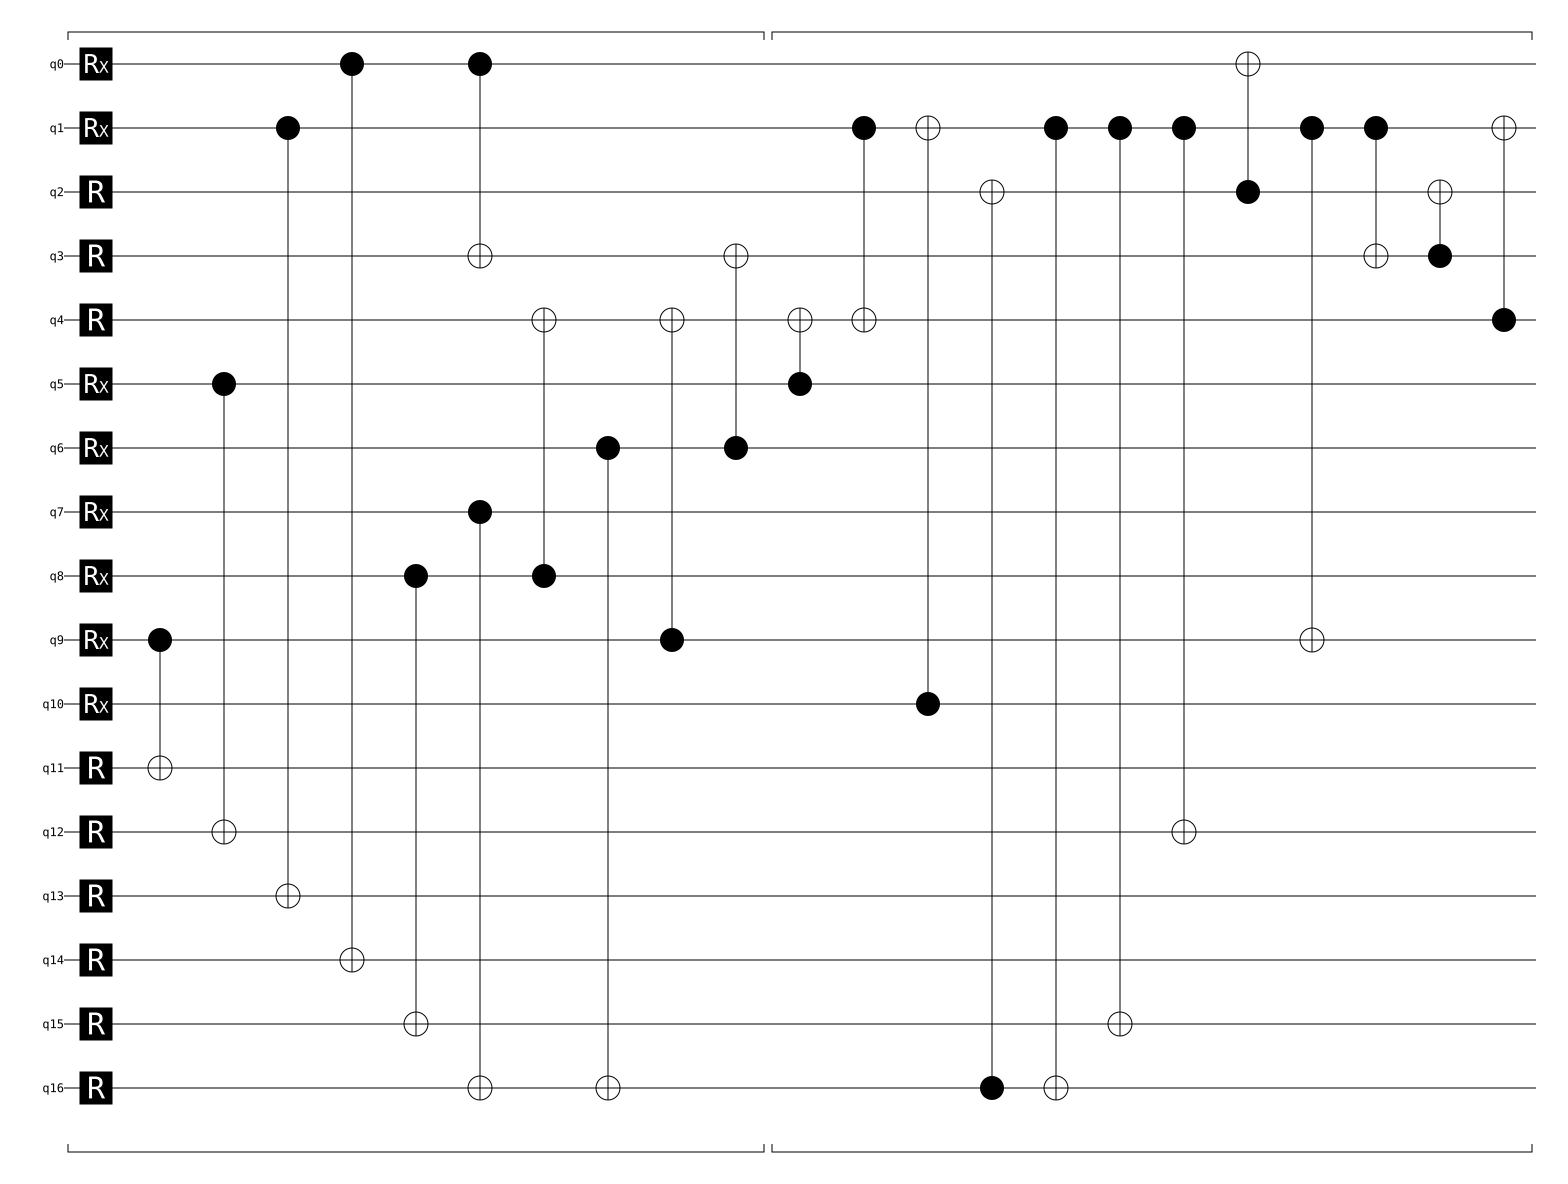

In [32]:
import stim
import networkx as nx
import matplotlib.pyplot as plt

from spidercss.draw import draw_forest_on_graph, display_digraph
from spidercss.utils import get_project_root
from spidercss.stim_utils import explode_circuit, SPECIAL_GATES

file = get_project_root().joinpath("good_circuits", "17_1_5.stim")
raw_circ = file.read_text()
circ = stim.Circuit(raw_circ)
circ = circ[:8]

circ.diagram('timeline-svg')

In [33]:
def stim_to_dag(circ: stim.Circuit) -> nx.DiGraph:
    dag = nx.DiGraph()
    ops = explode_circuit(circ)
    # Maps a qubit index to the node ID of the last operation that acted on it
    last_op_on_qubit = {}

    for op_id, op in enumerate(ops):
        name = op.name
        if name in SPECIAL_GATES:
            continue
        qubits = tuple(t.value for t in op.targets_copy() if t.is_qubit_target)

        dag.add_node(op_id, name=name, targets=qubits)

        for q in qubits:
            if q in last_op_on_qubit:
                prev_node = last_op_on_qubit[q]
                # If edge exists (e.g., they share multiple qubits), add to the set
                if dag.has_edge(prev_node, op_id):
                    dag[prev_node][op_id]['qubits'].add(q)
                else:
                    dag.add_edge(prev_node, op_id, qubits={q})

            last_op_on_qubit[q] = op_id

    return dag

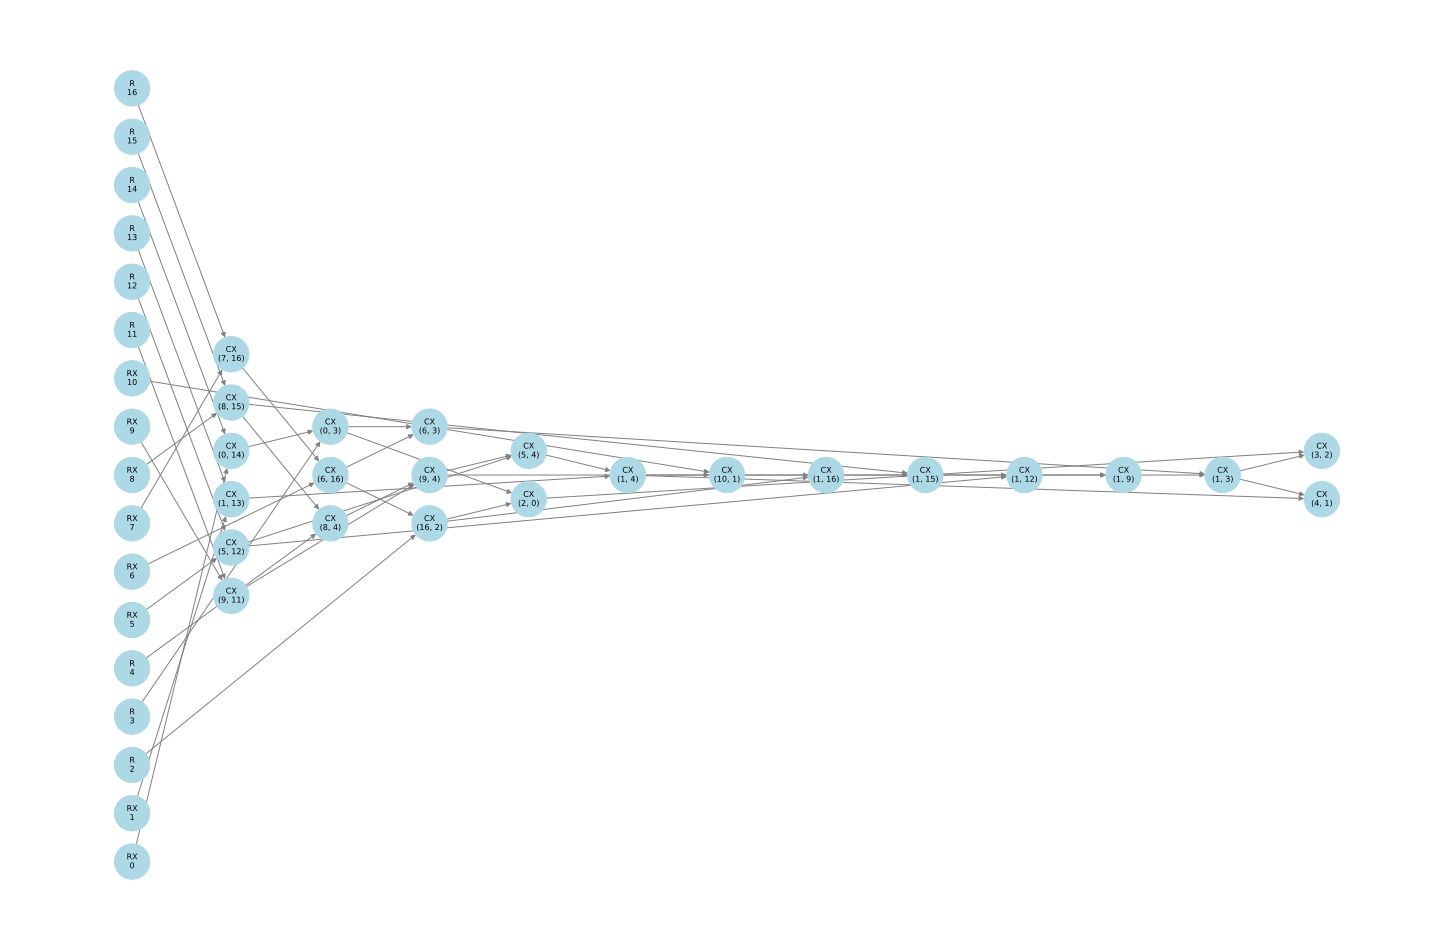

In [45]:
# Assuming `ops` is your exploded circuit
digraph = stim_to_dag(circ)

# 1. Assign topological layers
for layer, nodes in enumerate(nx.topological_generations(digraph)):
    for node in nodes:
        digraph.nodes[node]["layer"] = layer

# 2. Extract formatting data for nodes and edges
node_labels = {
    node: f"{data['name']}\n{data['targets'][0] if len(data['targets']) == 1 else data['targets']}"
    for node, data in digraph.nodes(data=True)
}

edge_labels = {
    (u, v): str(list(data['qubits'])[0])
    for u, v, data in digraph.edges(data=True)
}

# 3. Render
plt.figure(figsize=(20, 13))
pos = nx.multipartite_layout(digraph, subset_key="layer", align="vertical")

nx.draw(
    digraph, pos,
    with_labels=False, # Disable default ID labels
    node_size=1250,
    node_color="lightblue",
    edge_color="gray"
)

nx.draw_networkx_labels(digraph, pos, labels=node_labels, font_size=8)
# nx.draw_networkx_edge_labels(digraph, pos, edge_labels=edge_labels, font_size=7)

plt.show()